In [6]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [7]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

from utils.solver import Solver
from utils.vapour_reactor_utils import plot_reactor_solutions
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.interpolator import OpenMCTallyGridSurrogate

from coupled.vapour_reactor import VapourReactor

In [8]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    # data["HeatPipe"]["material"]["h_cond"] = 600

MODEL_PATH = Path("./utils/rgi_surrogate.joblib")
interpolator_model = OpenMCTallyGridSurrogate()
interpolator_model = interpolator_model.load(MODEL_PATH)

In [ ]:
Ns = [15, 30, 30]
cfg = generate_config(data, *Ns)
cfg_interp = generate_config(data, *Ns)

reactor = VapourReactor(cfg)

reactor_interp = VapourReactor(cfg_interp)
reactor_interp.set_interpolator_model(interpolator_model)

solver = Solver([reactor, reactor_interp], iterate=True)
solver.fsolve()

Mesh warning: N_Z changed from 30 to 23
Mesh warning: Fuel pin N_Z changed from 13 to 15
Mesh warning: Neutronics N_Z changed from 13 to 15
Mesh warning: N_Z changed from 30 to 23
Mesh warning: Fuel pin N_Z changed from 13 to 15
Mesh warning: Neutronics N_Z changed from 13 to 15
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 1 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 2 ...
fsolve message: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.


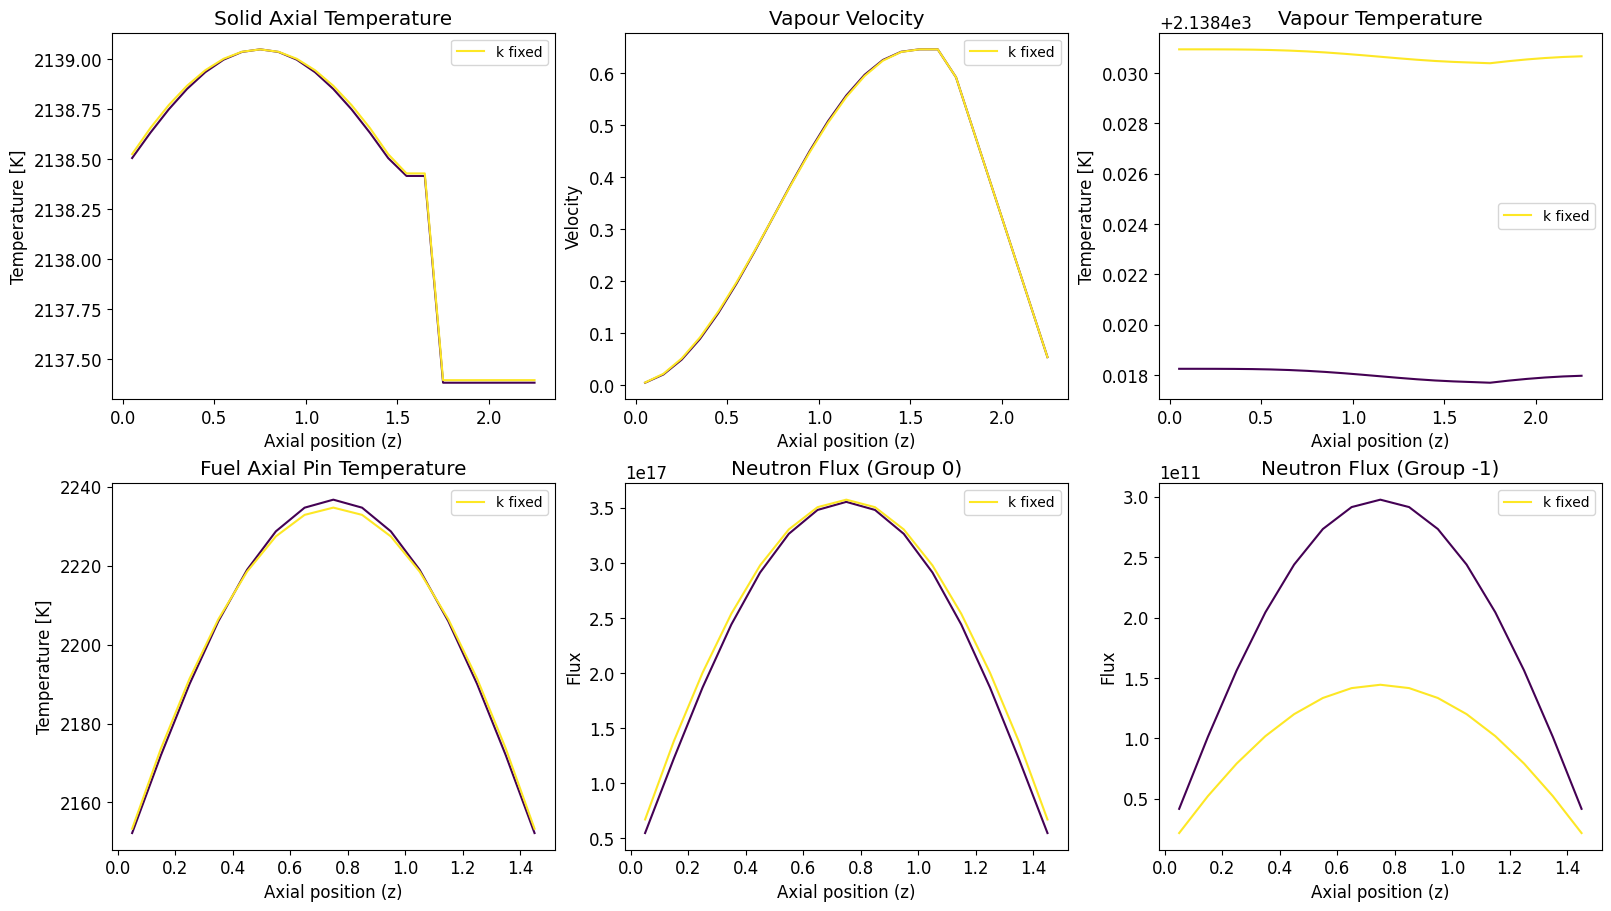

In [10]:
plot_reactor_solutions(solver)